Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Importing libraries required for Machine Learning

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score

Loading Dataset

In [3]:
data = pd.read_csv("creditcard.csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Separating Features and Target

In [4]:
X = data.drop("Class", axis=1)
y = data["Class"]

Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Training Decision Tree Model

In [7]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Making predictions

In [8]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

Confusion matrix

In [9]:
cm = confusion_matrix(y_test, y_prob)
print(cm)

[[56830    34]
 [   20    78]]


Classification report

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.70      0.80      0.74        98

    accuracy                           1.00     56962
   macro avg       0.85      0.90      0.87     56962
weighted avg       1.00      1.00      1.00     56962



ROC curve

Calculating FPR & TPR

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

Calculating AUC

In [12]:
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

AUC: 0.8976602247539421


Decision Tree with pruning 

In [13]:
pruned_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42
)

pruned_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, min_samples_split=50,
                       random_state=42)

Prediction

In [14]:
y_pred_pruned = pruned_model.predict(X_test)
y_prob_pruned = pruned_model.predict_proba(X_test)[:, 1]

Evaluating again

In [15]:
print(confusion_matrix(y_test, y_pred_pruned))
print(classification_report(y_test, y_pred_pruned))
print("AUC:", roc_auc_score(y_test, y_prob_pruned))

[[56858     6]
 [   24    74]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.76      0.83        98

    accuracy                           1.00     56962
   macro avg       0.96      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUC: 0.9553339941772994


Class weighted method

In [16]:
model_weighted = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

Fit the model

In [17]:
model_weighted.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

Predictions

In [18]:
y_pred_weighted = model_weighted.predict(X_test)
y_prob_weighted = model_weighted.predict_proba(X_test)[:, 1]

Evaluating performance

In [19]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print(confusion_matrix(y_test, y_pred_weighted))
print(classification_report(y_test, y_pred_weighted))
print("AUC:", roc_auc_score(y_test, y_prob_weighted))

[[56837    27]
 [   24    74]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.76      0.74        98

    accuracy                           1.00     56962
   macro avg       0.87      0.88      0.87     56962
weighted avg       1.00      1.00      1.00     56962

AUC: 0.8773136118544209


Plotting ROC curve

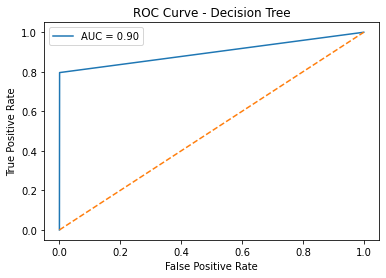

In [20]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

For this highly imbalanced dataset, pruning performs better than class weighting. Both methods achieve similar recall for the minority class, but pruning provides significantly higher precision and AUC, along with fewer false positives. This indicates that pruning effectively reduces overfitting while maintaining strong discrimination ability. Class weighting increases sensitivity toward the minority class but introduces more false positives, making it less suitable for this dataset.